# Corollary 4 — Grassmannian Subspace Distance: Verification Walkthrough

A short, results-first tour of the numerical verification of **Corollary 4** of
*Multifactor Dispersion Bias with Per-Column Prevalence*.

Where Equation (6) Part (ii) tracks each factor's eigenvector error *separately*,
Corollary 4 zooms out to the **whole loading subspace at once**. As $p \to \infty$
(conditional on $F$, a.s.) the squared Grassmannian distance between the sample
loading subspace $\mathrm{col}(H)$ and the population subspace $\mathrm{col}(\bar B)$
converges to the **sum of the per-factor floors**:

$$ d_{\mathrm{Gr}}^2\big(\mathrm{col}(H),\, \mathrm{col}(\bar B)\big)\ \longrightarrow\ \sum_{j} \frac{\delta^2}{n\rho_j + \delta^2}. $$

The in-subspace rotation cancels in the Grassmannian metric, so the subspace
distance is purely the sum of floors. Figures are rendered through the
`fl_graphics` / `fl_visualization` harness so they match the rest of the paper.

## Setup

In [7]:
%matplotlib inline
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from loguru import logger
logger.remove()  # keep the notebook quiet

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from sim_corollary4 import SubspaceDistanceExperiment, print_summary

# Importing fl_graphics registers the figures into the fl_visualization harness.
import fl_graphics
from fl_visualization import render_figures
from IPython.display import Image, display

print("ready — registered Corollary 4 figures:", fl_graphics.COROLLARY4_FIGURES)

ready — registered Corollary 4 figures: ['corollary4_convergence', 'corollary4_gap']


## 1 — Configure the model inline

The canonical diagonal-Gram parameters in **volatility** units (the engine squares
them into variances when it builds the model):

- a **market-like factor 1** with loadings $\beta_1 \sim N(1, 1)$, plus two
  zero-mean factors $\beta_2, \beta_3 \sim N(0, 1)$ — so the off-diagonal Gram
  entries vanish and $G_\infty = I_k$ holds;
- factor vols $\sigma = [0.16,\, 0.08,\, 0.06]$ (variances $[0.0256,\, 0.0064,\, 0.0036]$);
- constant idiosyncratic vol $0.4$, so $\delta^2 = 0.16$.

The design is a small smoke sweep over $p$ at fixed $n=60$; widen the commented line
for the fuller run.

In [8]:
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],                 # volatilities; squared into F
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 1.0},   # market-like factor
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},  # delta=0.4 -> delta^2=0.16
)

design = DesignSpec(
    n_values=[60],
    p_values=[200, 500, 1000, 2000, 5000],
    n_reps=40,
    random_seed=20260511,
    sampling="nested"
)
# Fuller sweep: design = DesignSpec(n_values=[30, 60, 120], n_reps=300)

dvars = [round(v ** 2, 4) for v in model.factor_vols]
print(f"k={model.k_factors}, factor_vols={model.factor_vols} -> variances={dvars}")

k=3, factor_vols=[0.16, 0.08, 0.06] -> variances=[0.0256, 0.0064, 0.0036]


## 2 — Run the sweep

`run_experiment(model, design, probe)` builds a fresh model per $(n, p)$ cell,
simulates `n_reps` replications, and for each runs the probe's two analyses: the new
`SubspaceDistanceAnalysis` (observed LHS) and the **reused** `Eq6RHSAnalysis` (whose
per-factor floors are summed for the prediction). The probe emits **one scalar row
per replication** — `(n, p, d_gr2_obs, d_gr2_pred, gap)`.

In [9]:
df = run_experiment(model, design, SubspaceDistanceExperiment(), progress=False)
print("rows:", len(df), " columns:", list(df.columns))
df.head()

rows: 200  columns: ['n', 'p', 'd_gr2_obs', 'd_gr2_pred', 'gap', 'rep']


,n,p,d_gr2_obs,d_gr2_pred,gap,rep
0,60,200,0.849979,0.832214,0.017765,0
1,60,500,0.915832,0.845598,0.070235,0
2,60,1000,0.895261,0.847110,0.048151,0
3,60,2000,0.850338,0.841115,0.009223,0
4,60,5000,0.849793,0.848407,0.001386,0


## 3 — The confirmation

The RMSE of the gap $\big(d_{\mathrm{Gr}}^2 - \sum_j \text{floor}_j\big)$ per $(n, p)$
should **fall as $p$ grows** — that decline is the numerical confirmation of
Corollary 4.

In [10]:
print_summary(df)


RMSE of (d_Gr² − Σ floors)  [smaller is better; should → 0 as p grows]

p     200     500     1000    2000    5000
n                                         
60 0.20030 0.08152 0.04373 0.02694 0.01485



## 4 — Figures (paper harness)

Rendered through `fl_graphics` for paper-grade styling. **`corollary4_convergence`**:
median observed $d_{\mathrm{Gr}}^2$ vs predicted $\sum_j \text{floor}_j$ across $p$, each
with a 25–75% inter-replication band — the two curves pull together as $p$ grows.
**`corollary4_gap`**: the gap RMSE on log–log axes, trending to zero.

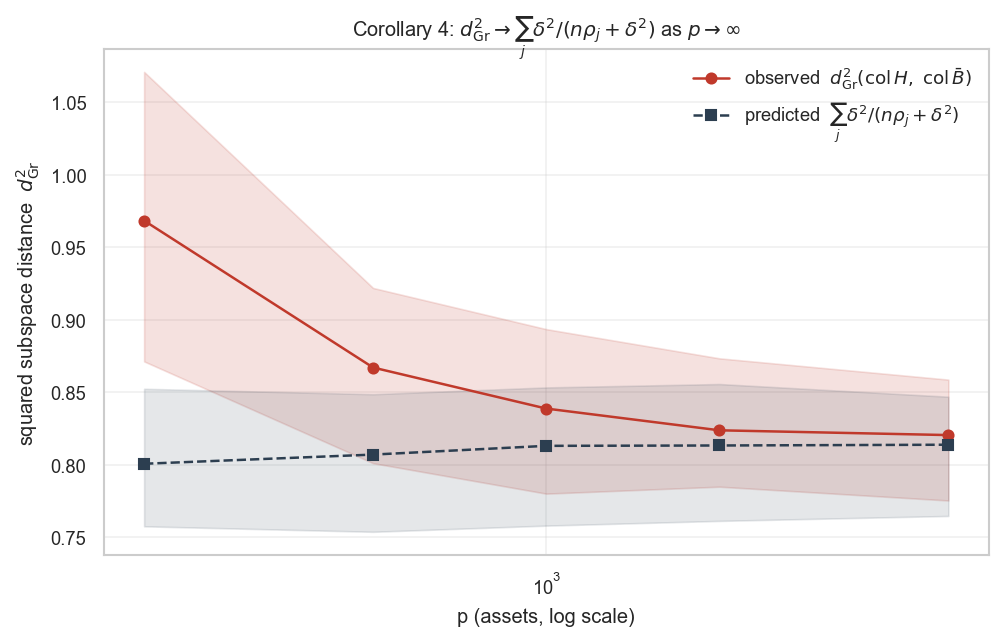

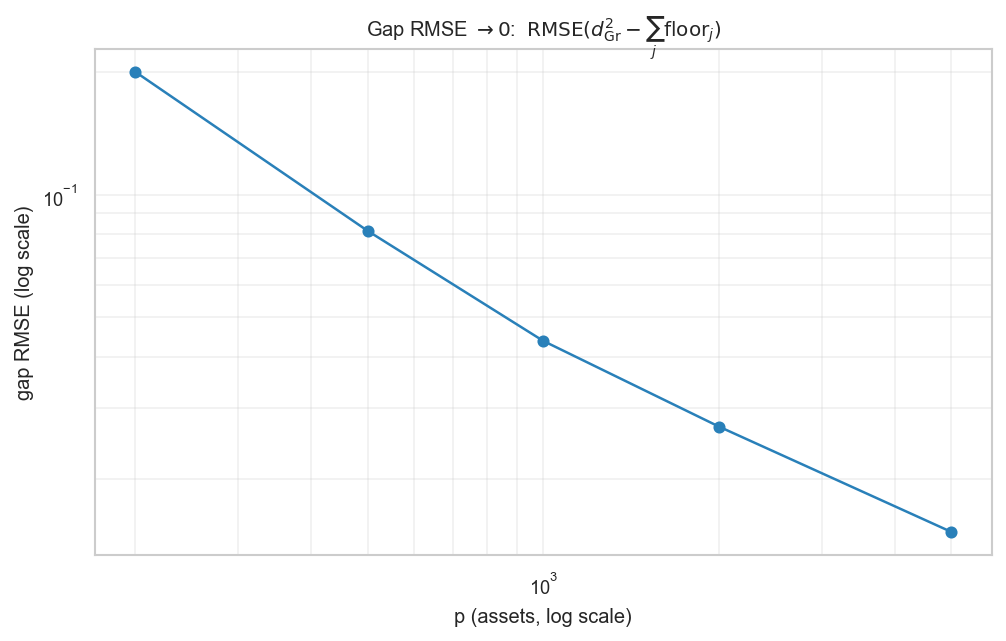

In [11]:
out_dir = Path("nb_outputs"); out_dir.mkdir(exist_ok=True)
paths = render_figures(df, out_dir, names=fl_graphics.COROLLARY4_FIGURES)
for name, pth in paths.items():
    display(Image(str(pth)))

## 5 — Cleaner convergence: nested sampling (diagnostic)

Setting `sampling="nested"` draws one superset model + returns at $p_{\max}$ per
replicate and takes each smaller $p$ as its first-$p$ asset subset — so every $p$
sees the *same* assets and factor realization, removing cross-$p$ sampling noise.
The probe is unchanged. This is a methodological aside (an independent-vs-nested
comparison over two dataframes), so it stays an inline plot rather than a registered
paper figure.

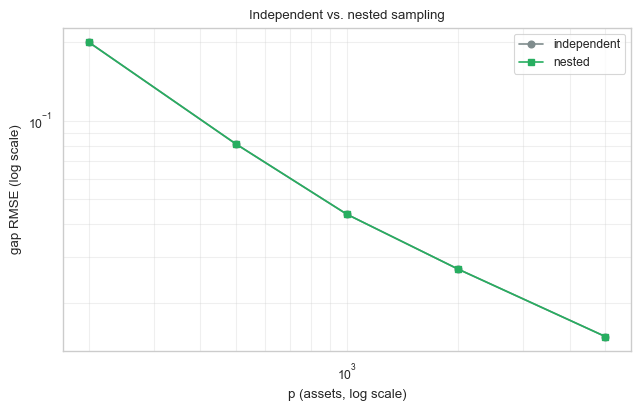

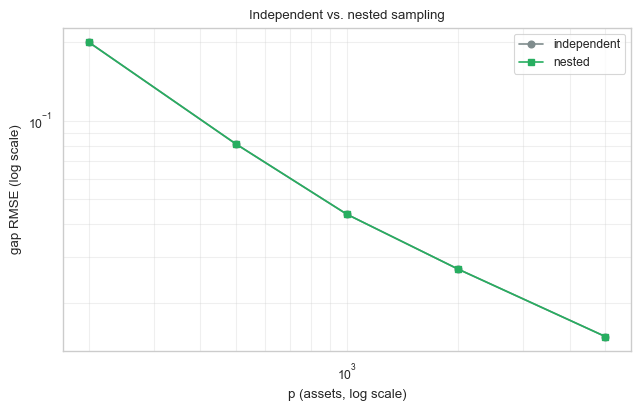

In [12]:

nested = DesignSpec(
    n_values=[60], p_values=[200, 500, 1000, 2000, 5000],
    n_reps=40, random_seed=20260511, sampling="nested",
)
df_nested = run_experiment(model, nested, SubspaceDistanceExperiment(), progress=False)

rmse_ind = df.groupby("p")["gap"].apply(lambda g: float(np.sqrt((g ** 2).mean())))
rmse_nst = df_nested.groupby("p")["gap"].apply(lambda g: float(np.sqrt((g ** 2).mean())))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(rmse_ind.index, rmse_ind.values, "o-", label="independent", color="#7f8c8d")
ax.plot(rmse_nst.index, rmse_nst.values, "s-", label="nested", color="#27ae60")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("p (assets, log scale)"); ax.set_ylabel("gap RMSE (log scale)")
ax.set_title("Independent vs. nested sampling")
ax.legend(); ax.grid(True, alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## Notes

- The model was specified **inline** here — no `model_spec.json` needed. The same
  `ModelSpec` could equally be referenced from a design JSON; the runtime object is
  identical either way.
- Corollary 4 reuses `Eq6RHSAnalysis` from the Part (ii) probe verbatim — only the
  observed-LHS analysis (`SubspaceDistanceAnalysis`) and the per-replication record
  schema are new. That is the extension pattern: a new question is a new `Experiment`,
  the engine and seams are untouched.
- The paper figures now live in `fl_graphics` (`corollary4_convergence`,
  `corollary4_gap`) and render through the same harness as the Theorem 1 figures.